# Trader Behavior vs Market Sentiment (Fear & Greed)

**Goal:** check if the Fear & Greed Index affects how traders behave and how much money they make.

**Data:**
- `historical_data.csv` – individual trade fills
- `fear_greed_index.csv` – daily Fear & Greed score

**Notebook flow:**
1. Load & clean data
2. Feature engineering
3. EDA
4. Statistical tests
5. Insights & conclusion

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pandasql import sqldf

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# helper so we can write SQL directly on our DataFrames
run_sql = lambda q: sqldf(q, globals())

PALETTE_SENTIMENT = {'Fear': '#d62728', 'Neutral': '#7f7f7f', 'Greed': '#2ca02c'}
PALETTE_FG = {'Extreme Fear': '#8b0000', 'Fear': '#d62728', 'Neutral': '#7f7f7f',
              'Greed': '#2ca02c', 'Extreme Greed': '#004d00'}

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Part A — Data Preparation

### Step 1: Load the data

Two files:
- `historical_data.csv` — one row per trade fill
- `fear_greed_index.csv` — one row per day, sentiment score (0-100)

In [2]:
trades_raw = pd.read_csv('/mnt/user-data/uploads/historical_data.csv')
fg_raw = pd.read_csv('/mnt/user-data/uploads/fear_greed_index.csv')

print("HISTORICAL TRADING DATA")
print("-"*60)
print(f"Shape: {trades_raw.shape}  |  Rows: {trades_raw.shape[0]:,}  |  Columns: {trades_raw.shape[1]}")
print(f"Memory usage: {trades_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nColumn names:", list(trades_raw.columns))

HISTORICAL TRADING DATA
------------------------------------------------------------
Shape: (211224, 16)  |  Rows: 211,224  |  Columns: 16


Memory usage: 102.20 MB

Column names: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [3]:
print("Data types:")
trades_raw.dtypes

Data types:


Account                 str
Coin                    str
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                    str
Timestamp IST           str
Start Position      float64
Direction               str
Closed PnL          float64
Transaction Hash        str
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64
dtype: object

In [4]:
print("First 5 rows:")
trades_raw.head()

First 5 rows:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
print("Last 5 rows:")
trades_raw.tail()

Last 5 rows:


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,382.2,420.80,SELL,25-04-2025 15:35,7546.6,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,2124.1,2338.63,SELL,25-04-2025 15:35,7164.4,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,423.4,466.16,SELL,25-04-2025 15:35,5040.3,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,3599.8,3963.38,SELL,25-04-2025 15:35,4616.9,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12
211223,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,1017.1,1119.83,SELL,25-04-2025 15:35,1017.1,Close Long,-53.9063,0xac77fab973c455d77a670422374d9602039800f1f78c...,88803313862,False,0.111982,3.270000e+14,1.750000e+12


In [6]:
print("FEAR & GREED INDEX DATA")
print("-"*60)
print(f"Shape: {fg_raw.shape}  |  Rows: {fg_raw.shape[0]:,}  |  Columns: {fg_raw.shape[1]}")
print(f"Memory usage: {fg_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nColumn names:", list(fg_raw.columns))
fg_raw.dtypes

FEAR & GREED INDEX DATA
------------------------------------------------------------
Shape: (2644, 4)  |  Rows: 2,644  |  Columns: 4
Memory usage: 0.33 MB

Column names: ['timestamp', 'value', 'classification', 'date']


timestamp         int64
value             int64
classification      str
date                str
dtype: object

In [7]:
print("First 5 rows:")
display(fg_raw.head())
print("Last 5 rows:")
display(fg_raw.tail())

First 5 rows:


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


Last 5 rows:


,timestamp,value,classification,date
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01
2643,1746163800,67,Greed,2025-05-02


**About the columns:**
- `historical_data.csv`: each row is a trade *fill*, not a closed position. Key columns: `Account`, `Coin`, `Execution Price`, `Size USD`, `Side`, `Closed PnL`, `Fee`.
- `fear_greed_index.csv`: one row per day — sentiment `value` (0-100) and `classification` (Extreme Fear → Extreme Greed), 2018-2025.

**Important:** `Closed PnL` is 0 for trades that *open* a position and non-zero only for trades that *close/reduce* one. So win rate and PnL are only calculated over these "realized" trades.

### Step 2: Data quality check

In [8]:
def data_quality_report(df, name):
    report = pd.DataFrame({
        'dtype': df.dtypes,
        'n_missing': df.isnull().sum(),
        'pct_missing': (df.isnull().sum() / len(df) * 100).round(2),
        'n_unique': df.nunique(),
    })
    print(f"=== Data Quality Report: {name} ===")
    display(report)
    print(f"Duplicate rows: {df.duplicated().sum():,}")
    return report

dq_trades = data_quality_report(trades_raw, "historical_data.csv")

=== Data Quality Report: historical_data.csv ===


,dtype,n_missing,pct_missing,n_unique,cardinality_pct
Account,str,0,0.0,32,0.02
Coin,str,0,0.0,246,0.12
Execution Price,float64,0,0.0,60162,28.48
Size Tokens,float64,0,0.0,59304,28.08
Size USD,float64,0,0.0,118493,56.10
Side,str,0,0.0,2,0.00
Timestamp IST,str,0,0.0,27977,13.25
Start Position,float64,0,0.0,196923,93.23
Direction,str,0,0.0,12,0.01
Closed PnL,float64,0,0.0,90720,42.95


Duplicate rows (all columns identical): 0


In [9]:
dq_fg = data_quality_report(fg_raw, "fear_greed_index.csv")

=== Data Quality Report: fear_greed_index.csv ===


,dtype,n_missing,pct_missing,n_unique,cardinality_pct
timestamp,int64,0,0.0,2644,100.00
value,int64,0,0.0,90,3.40
classification,str,0,0.0,5,0.19
date,str,0,0.0,2644,100.00


Duplicate rows (all columns identical): 0


In [10]:
print("Duplicate 'Trade ID' rows:", trades_raw.duplicated(subset=['Trade ID']).sum())
print("Duplicate 'Order ID' rows:", trades_raw.duplicated(subset=['Order ID']).sum())
print("Duplicate ('Transaction Hash','Trade ID') combos:",
      trades_raw.duplicated(subset=['Transaction Hash','Trade ID']).sum())
print()
print("NOTE: 'Trade ID' repeats because a single blockchain trade can generate multiple")
print("fill rows (partial fills against multiple counterparties). 'Order ID' repeats when")
print("one order is filled in multiple pieces. These are legitimate, not data errors.")
print()
print("Duplicate dates in fear_greed_index.csv:", fg_raw.duplicated(subset=['date']).sum())

Duplicate 'Trade ID' rows: 208414
Duplicate 'Order ID' rows: 160669
Duplicate ('Transaction Hash','Trade ID') combos: 10105

NOTE: 'Trade ID' repeats because a single blockchain trade can generate multiple
fill rows (partial fills against multiple counterparties). 'Order ID' repeats when
one order is filled in multiple pieces. These are legitimate, not data errors.

Duplicate dates in fear_greed_index.csv: 0


In [11]:
print("Negative Execution Price:", (trades_raw['Execution Price'] < 0).sum())
print("Negative Size Tokens:", (trades_raw['Size Tokens'] < 0).sum())
print("Negative Size USD:", (trades_raw['Size USD'] < 0).sum())
print("Zero Size USD (near-dust trades):", (trades_raw['Size USD'] == 0).sum())
print("Negative Fee (fee rebates - can be legitimate on some exchanges):", (trades_raw['Fee'] < 0).sum())
print()
print("Side unique values:", trades_raw['Side'].unique())
print("Direction unique values:", trades_raw['Direction'].unique())
print("Crossed unique values:", trades_raw['Crossed'].unique())
print()
print("Fear & Greed 'value' range:", fg_raw['value'].min(), "-", fg_raw['value'].max())
print("Fear & Greed 'classification' unique values:", fg_raw['classification'].unique())

Negative Execution Price: 0
Negative Size Tokens: 0
Negative Size USD: 0
Zero Size USD (near-dust trades): 43
Negative Fee (fee rebates - can be legitimate on some exchanges): 2476

Side unique values: <StringArray>
['BUY', 'SELL']
Length: 2, dtype: str
Direction unique values: <StringArray>
[                      'Buy',                      'Sell',                 'Open Long',                'Close Long',      'Spot Dust Conversion',
                'Open Short',               'Close Short',              'Long > Short',              'Short > Long',         'Auto-Deleveraging',
 'Liquidated Isolated Short',                'Settlement']
Length: 12, dtype: str
Crossed unique values: [ True False]

Fear & Greed 'value' range: 5 - 95
Fear & Greed 'classification' unique values: <StringArray>
['Fear', 'Extreme Fear', 'Neutral', 'Greed', 'Extreme Greed']
Length: 5, dtype: str


In [12]:
# IQR based outlier check
def iqr_outlier_pct(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return ((series < lower) | (series > upper)).mean() * 100

for col in ['Execution Price', 'Size USD', 'Closed PnL', 'Fee']:
    print(f"{col}: {iqr_outlier_pct(trades_raw[col]):.2f}% flagged as IQR outliers "
          f"(min={trades_raw[col].min():,.2f}, max={trades_raw[col].max():,.2f})")

Execution Price: 19.97% flagged as IQR outliers (min=0.00, max=109,004.00)
Size USD: 15.46% flagged as IQR outliers (min=0.00, max=3,921,430.72)
Closed PnL: 23.17% flagged as IQR outliers (min=-117,990.10, max=135,329.09)
Fee: 14.33% flagged as IQR outliers (min=-1.18, max=837.47)


**Data quality summary:**

| Check | Result |
|---|---|
| Missing values | None |
| Fully duplicate rows | None |
| Duplicate `Trade ID` / `Order ID` | Expected (multi-fill orders), not an error |
| Negative price/size | None |
| Zero `Size USD` | Small number of dust trades, kept |
| Negative fees | A few legitimate rebates, kept |
| Outliers (IQR) | Present in `Size USD`, `Closed PnL`, `Fee` — expected for trading data, so kept and handled with median + robust tests later |
| Date coverage | Trades: 2023-05-01 to 2025-05-01. Sentiment: 2018-02-01 to 2025-05-02 (fully covers trading window) |

### Step 3: Data cleaning

1. Strip whitespace and standardize case for text columns
2. Drop exact duplicate rows (defensive — none found)
3. No missing values to fill
4. Keep negative/zero values — they're real (rebates, dust trades, losses)
5. Keep outliers — heavy tails are a real feature of trading data
6. Clean and parse the Fear & Greed `date`/`classification` columns

In [13]:
trades = trades_raw.copy()

# Standardize text columns
for col in ['Coin', 'Side', 'Direction', 'Transaction Hash']:
    trades[col] = trades[col].astype(str).str.strip()
trades['Account'] = trades['Account'].astype(str).str.strip().str.lower()
trades['Side'] = trades['Side'].str.upper()

before = len(trades)
trades = trades.drop_duplicates()
print(f"Dropped {before - len(trades)} exact duplicate rows.")

fg = fg_raw.copy()
fg.columns = [c.strip() for c in fg.columns]
fg['classification'] = fg['classification'].astype(str).str.strip()
fg['date'] = pd.to_datetime(fg['date'])
fg = fg.drop_duplicates(subset=['date']).sort_values('date').reset_index(drop=True)

print("Cleaning complete.")
print(f"Trades: {trades.shape} | Fear & Greed: {fg.shape}")

Dropped 0 exact duplicate rows.
Cleaning complete.
Trades: (211224, 16) | Fear & Greed: (2644, 4)


### Step 4: Timestamp processing

In [14]:
trades['datetime'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
print("Unparseable timestamps:", trades['datetime'].isnull().sum())

# Daily date, used to join with the Fear & Greed index
trades['date'] = trades['datetime'].dt.normalize()

trades['Year'] = trades['datetime'].dt.year
trades['Quarter'] = trades['datetime'].dt.quarter
trades['Month'] = trades['datetime'].dt.month
trades['Week'] = trades['datetime'].dt.isocalendar().week.astype(int)
trades['Day'] = trades['datetime'].dt.day
trades['DayName'] = trades['datetime'].dt.day_name()
trades['IsWeekend'] = trades['datetime'].dt.dayofweek >= 5

print(f"Trading data date range: {trades['date'].min().date()} to {trades['date'].max().date()}")
print(f"Number of unique trading days: {trades['date'].nunique()}")
trades[['Timestamp IST','datetime','date','Year','Quarter','Month','Week','DayName','IsWeekend']].head()

Unparseable timestamps: 0
Trading data date range: 2023-05-01 to 2025-05-01
Number of unique trading days: 480


,Timestamp IST,datetime,date,Year,Quarter,Month,Week,DayName,IsWeekend
0,02-12-2024 22:50,2024-12-02 22:50:00,2024-12-02,2024,4,12,49,Monday,False
1,02-12-2024 22:50,2024-12-02 22:50:00,2024-12-02,2024,4,12,49,Monday,False
2,02-12-2024 22:50,2024-12-02 22:50:00,2024-12-02,2024,4,12,49,Monday,False
3,02-12-2024 22:50,2024-12-02 22:50:00,2024-12-02,2024,4,12,49,Monday,False
4,02-12-2024 22:50,2024-12-02 22:50:00,2024-12-02,2024,4,12,49,Monday,False


### Step 5: Merge the datasets

Merge type: **LEFT join**, trades → Fear & Greed index, on `date`.

We use a left join so every trade row is kept — the sentiment index is just a daily lookup table added on top.

In [15]:
merged = trades.merge(
    fg[['date', 'value', 'classification']],
    on='date', how='left', validate='m:1'
)

n_unmatched = merged['classification'].isnull().sum()
unmatched_dates = merged.loc[merged['classification'].isnull(), 'date'].unique()
print(f"Rows before merge: {len(trades):,} | Rows after merge: {len(merged):,}")
print(f"Unmatched trade rows (no Fear & Greed value for that date): {n_unmatched} "
      f"({n_unmatched/len(merged)*100:.3f}%)")
print("Unmatched date(s):", [str(d)[:10] for d in unmatched_dates])

assert len(merged) == len(trades), "Row count changed unexpectedly during merge!"

# Drop the tiny number of unmatched rows and bucket sentiment
merged = merged.dropna(subset=['classification']).copy()

def bucket_sentiment(c):
    if c in ['Fear', 'Extreme Fear']:
        return 'Fear'
    elif c in ['Greed', 'Extreme Greed']:
        return 'Greed'
    return 'Neutral'

merged['SentimentGroup'] = merged['classification'].apply(bucket_sentiment)
merged['LongShort'] = np.where(merged['Side'] == 'BUY', 'Long', 'Short')
merged['IsRealized'] = merged['Closed PnL'] != 0
merged['IsWin'] = merged['Closed PnL'] > 0

print("\nFinal merged dataset shape:", merged.shape)
print("\nSentiment group distribution (trade-level):")
print(merged['SentimentGroup'].value_counts())

Rows before merge: 211,224 | Rows after merge: 211,224
Unmatched trade rows (no Fear & Greed value for that date): 6 (0.003%)
Unmatched date(s): ['2024-10-26']



Final merged dataset shape: (211218, 31)

Sentiment group distribution (trade-level):
SentimentGroup
Greed      90295
Fear       83237
Neutral    37686
Name: count, dtype: int64


**Merge check:** row count is unchanged apart from 6 rows with no matching sentiment date (0.003% of data). `validate='m:1'` confirms no row duplication happened.

## Feature Engineering

We build two tables:
- **Trader-Day** — one row per `(Account, date)`, used for behavior and statistical tests
- **Market-Day** — one row per `date`, used for time-series and market-wide trends

**Key metrics:** Daily PnL, win rate, trade size, trade frequency, long/short ratio, cumulative PnL, drawdown, rolling PnL.

**Note:** there's no `Leverage` column in the data, so trade size (USD) is used as the closest proxy for risk-taking.

In [16]:
def agg_trader_day(g):
    realized = g[g['IsRealized']]
    wins = realized[realized['IsWin']]
    losses = realized[~realized['IsWin']]
    return pd.Series({
        'NumTrades': len(g),
        'TotalVolumeUSD': g['Size USD'].sum(),
        'AvgTradeSize': g['Size USD'].mean(),
        'MedianTradeSize': g['Size USD'].median(),
        'LongTrades': (g['LongShort'] == 'Long').sum(),
        'ShortTrades': (g['LongShort'] == 'Short').sum(),
        'DailyPnL': realized['Closed PnL'].sum(),
        'NumRealized': len(realized),
        'NumWins': len(wins),
        'NumLosses': len(losses),
        'AvgWin': wins['Closed PnL'].mean() if len(wins) > 0 else 0.0,
        'AvgLoss': losses['Closed PnL'].mean() if len(losses) > 0 else 0.0,
        'TotalFees': g['Fee'].sum(),
        'SentimentGroup': g['SentimentGroup'].iloc[0],
        'classification': g['classification'].iloc[0],
        'FGValue': g['value'].iloc[0],
    })

trader_day = (merged.groupby(['Account', 'date'])
              .apply(agg_trader_day, include_groups=False)
              .reset_index())

trader_day['WinRate'] = np.where(trader_day['NumRealized'] > 0,
                                  trader_day['NumWins'] / trader_day['NumRealized'], np.nan)
trader_day['LongShortRatio'] = trader_day['LongTrades'] / trader_day['ShortTrades'].replace(0, np.nan)

print(f"Trader-Day level dataset: {trader_day.shape[0]:,} rows "
      f"({trader_day['Account'].nunique()} traders x avg "
      f"{trader_day.groupby('Account')['date'].nunique().mean():.0f} active days each)")
trader_day.head()

Trader-Day level dataset: 2,340 rows (32 traders x avg 73 active days each)


,Account,date,NumTrades,TotalVolumeUSD,AvgTradeSize,MedianTradeSize,LongTrades,ShortTrades,DailyPnL,NumRealized,NumWins,NumLosses,AvgWin,AvgLoss,TotalFees,SentimentGroup,classification,FGValue,WinRate,LongShortRatio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177,900880.13,5089.718249,2736.64,0,177,0.0,0,0,0,0.000000,0.000000,167.796055,Greed,Extreme Greed,76.0,NaN,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,68,542413.18,7976.664412,2340.00,0,68,0.0,0,0,0,0.000000,0.000000,67.883615,Greed,Extreme Greed,90.0,NaN,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,40,949380.00,23734.500000,3594.51,0,40,0.0,0,0,0,0.000000,0.000000,94.937983,Greed,Extreme Greed,83.0,NaN,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,12,338240.00,28186.666667,29307.14,12,0,-21227.0,12,0,12,0.000000,-1768.916667,33.823995,Greed,Extreme Greed,94.0,0.0,NaN
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,27,465700.00,17248.148148,8898.30,12,15,1603.1,12,12,0,133.591667,0.000000,104.622490,Greed,Extreme Greed,79.0,1.0,0.8


In [17]:
def agg_market_day(g):
    realized = g[g['IsRealized']]
    wins = realized[realized['IsWin']]
    return pd.Series({
        'NumTrades': len(g),
        'ActiveTraders': g['Account'].nunique(),
        'TotalVolumeUSD': g['Size USD'].sum(),
        'AvgTradeSize': g['Size USD'].mean(),
        'DailyPnL': realized['Closed PnL'].sum(),
        'NumRealized': len(realized),
        'NumWins': len(wins),
        'LongTrades': (g['LongShort'] == 'Long').sum(),
        'ShortTrades': (g['LongShort'] == 'Short').sum(),
        'SentimentGroup': g['SentimentGroup'].iloc[0],
        'classification': g['classification'].iloc[0],
        'FGValue': g['value'].iloc[0],
    })

daily = (merged.groupby('date').apply(agg_market_day, include_groups=False)
         .reset_index().sort_values('date').reset_index(drop=True))

daily['WinRate'] = daily['NumWins'] / daily['NumRealized']
daily['LongShortRatio'] = daily['LongTrades'] / daily['ShortTrades'].replace(0, np.nan)
daily['CumulativePnL'] = daily['DailyPnL'].cumsum()
daily['RunningPeak'] = daily['CumulativePnL'].cummax()
daily['DrawdownProxy'] = daily['CumulativePnL'] - daily['RunningPeak']
daily['RollingPnL_7d'] = daily['DailyPnL'].rolling(7, min_periods=1).mean()
daily['TradesPerActiveTrader'] = daily['NumTrades'] / daily['ActiveTraders']

print(f"Market-Day level dataset: {daily.shape[0]} trading days")
daily.head()

Market-Day level dataset: 479 trading days


,date,NumTrades,ActiveTraders,TotalVolumeUSD,AvgTradeSize,DailyPnL,NumRealized,NumWins,LongTrades,ShortTrades,SentimentGroup,classification,FGValue,WinRate,LongShortRatio,CumulativePnL,RunningPeak,DrawdownProxy,RollingPnL_7d,TradesPerActiveTrader
0,2023-05-01,3,1,477.00,159.000000,0.000000,0,0,3,0,Greed,Greed,63.0,NaN,NaN,0.000000,0.0,0.000000,0.000000,3.0
1,2023-12-05,9,1,50005.83,5556.203333,0.000000,0,0,7,2,Greed,Extreme Greed,75.0,NaN,3.500000,0.000000,0.0,0.000000,0.000000,9.0
2,2023-12-14,11,1,113203.35,10291.213636,-205.434737,6,4,5,6,Greed,Greed,72.0,0.666667,0.833333,-205.434737,0.0,-205.434737,-68.478246,11.0
3,2023-12-15,2,1,10609.95,5304.975000,-24.632034,2,0,2,0,Greed,Greed,70.0,0.000000,NaN,-230.066771,0.0,-230.066771,-57.516693,2.0
4,2023-12-16,3,1,15348.77,5116.256667,0.000000,0,0,3,0,Greed,Greed,67.0,NaN,NaN,-230.066771,0.0,-230.066771,-46.013354,3.0


In [18]:
# Trade-size buckets, used as a risk-taking proxy since leverage isn't in the data
size_bins = [-0.01, 200, 2000, np.inf]
size_labels = ['Small (<$200)', 'Medium ($200-$2K)', 'Large (>$2K)']
merged['TradeSizeCategory'] = pd.cut(merged['Size USD'], bins=size_bins, labels=size_labels)
print(merged['TradeSizeCategory'].value_counts())

TradeSizeCategory
Medium ($200-$2K)    100376
Large (>$2K)          55844
Small (<$200)         54998
Name: count, dtype: int64


## Part B — Exploratory Data Analysis

### Univariate analysis — numeric columns

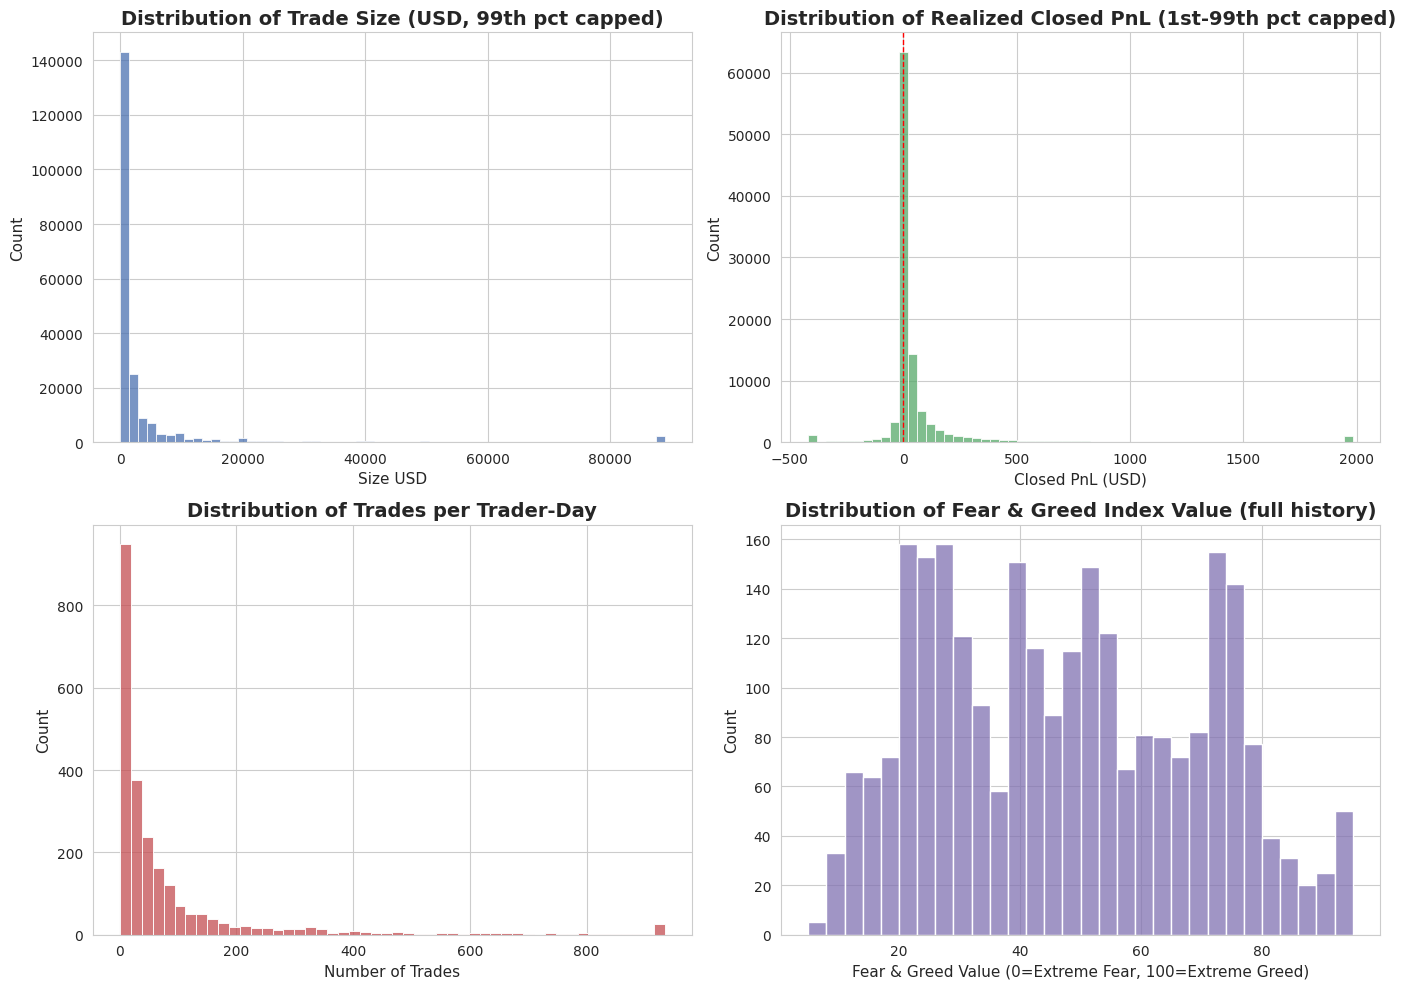

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(merged['Size USD'].clip(upper=merged['Size USD'].quantile(0.99)),
             bins=60, ax=axes[0,0], color='#4c72b0')
axes[0,0].set_title('Trade Size Distribution (99th pct capped)')
axes[0,0].set_xlabel('Size USD')

realized_pnl = merged.loc[merged['IsRealized'], 'Closed PnL']
sns.histplot(realized_pnl.clip(lower=realized_pnl.quantile(0.01), upper=realized_pnl.quantile(0.99)),
             bins=60, ax=axes[0,1], color='#55a868')
axes[0,1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0,1].set_title('Realized PnL Distribution (1st-99th pct capped)')
axes[0,1].set_xlabel('Closed PnL (USD)')

sns.histplot(trader_day['NumTrades'].clip(upper=trader_day['NumTrades'].quantile(0.99)),
             bins=50, ax=axes[1,0], color='#c44e52')
axes[1,0].set_title('Trades per Trader-Day')
axes[1,0].set_xlabel('Number of Trades')

sns.histplot(fg['value'], bins=30, ax=axes[1,1], color='#8172b2')
axes[1,1].set_title('Fear & Greed Index Distribution (full history)')
axes[1,1].set_xlabel('Fear & Greed Value (0=Extreme Fear, 100=Extreme Greed)')

plt.tight_layout()
plt.show()

**Takeaway:** trade size and realized PnL are both right-skewed with fat tails — typical for crypto derivatives. Trades-per-day is also skewed, likely from a few high-frequency accounts. The Fear & Greed index is fairly evenly spread historically, slightly concentrated around Fear/Neutral.

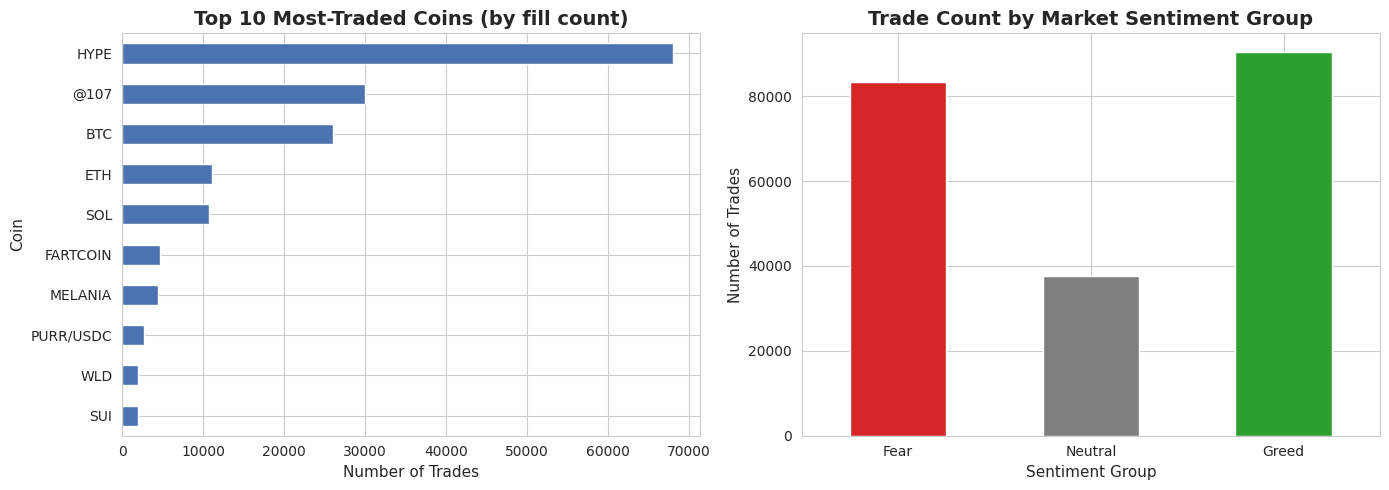

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

merged['Coin'].value_counts().head(10).plot(kind='barh', ax=axes[0], color='#4c72b0')
axes[0].set_title('Top 10 Most-Traded Coins')
axes[0].set_xlabel('Number of Trades')
axes[0].invert_yaxis()

merged['SentimentGroup'].value_counts().reindex(['Fear','Neutral','Greed']).plot(
    kind='bar', ax=axes[1], color=[PALETTE_SENTIMENT[s] for s in ['Fear','Neutral','Greed']])
axes[1].set_title('Trade Count by Sentiment Group')
axes[1].set_xlabel('Sentiment Group')
axes[1].set_ylabel('Number of Trades')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Takeaway:** a handful of coins dominate volume. Trading is not evenly spread across sentiment — more trades happen during Greed than Fear, a first hint that traders get more active when the market is bullish.

### Univariate analysis — categorical columns

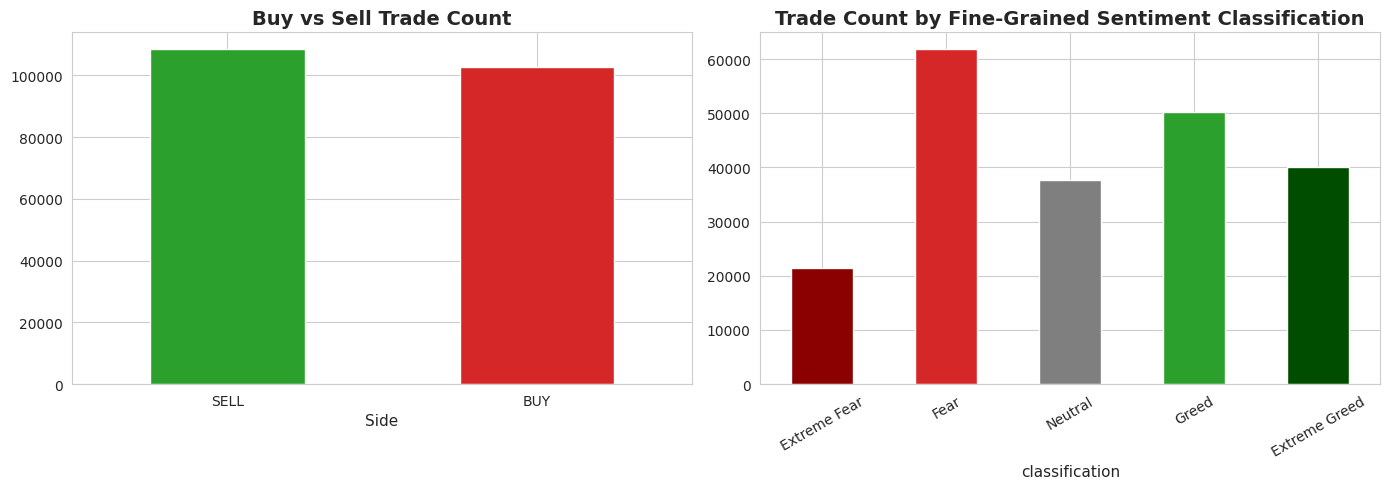

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

merged['Side'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ca02c', '#d62728'])
axes[0].set_title('Buy vs Sell Trade Count')
axes[0].tick_params(axis='x', rotation=0)

order_fg = ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']
merged['classification'].value_counts().reindex(order_fg).plot(
    kind='bar', ax=axes[1], color=[PALETTE_FG[c] for c in order_fg])
axes[1].set_title('Trade Count by Sentiment Classification')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Takeaway:** buy/sell counts are roughly balanced (every closed trade needs an offsetting fill). Trading activity skews toward the moderate "Fear"/"Greed" labels rather than the extreme ones.

### Bivariate analysis

Looking at PnL, win rate, trade size and trade frequency against sentiment, using the trader-day table so every row is one trader's activity on one day.

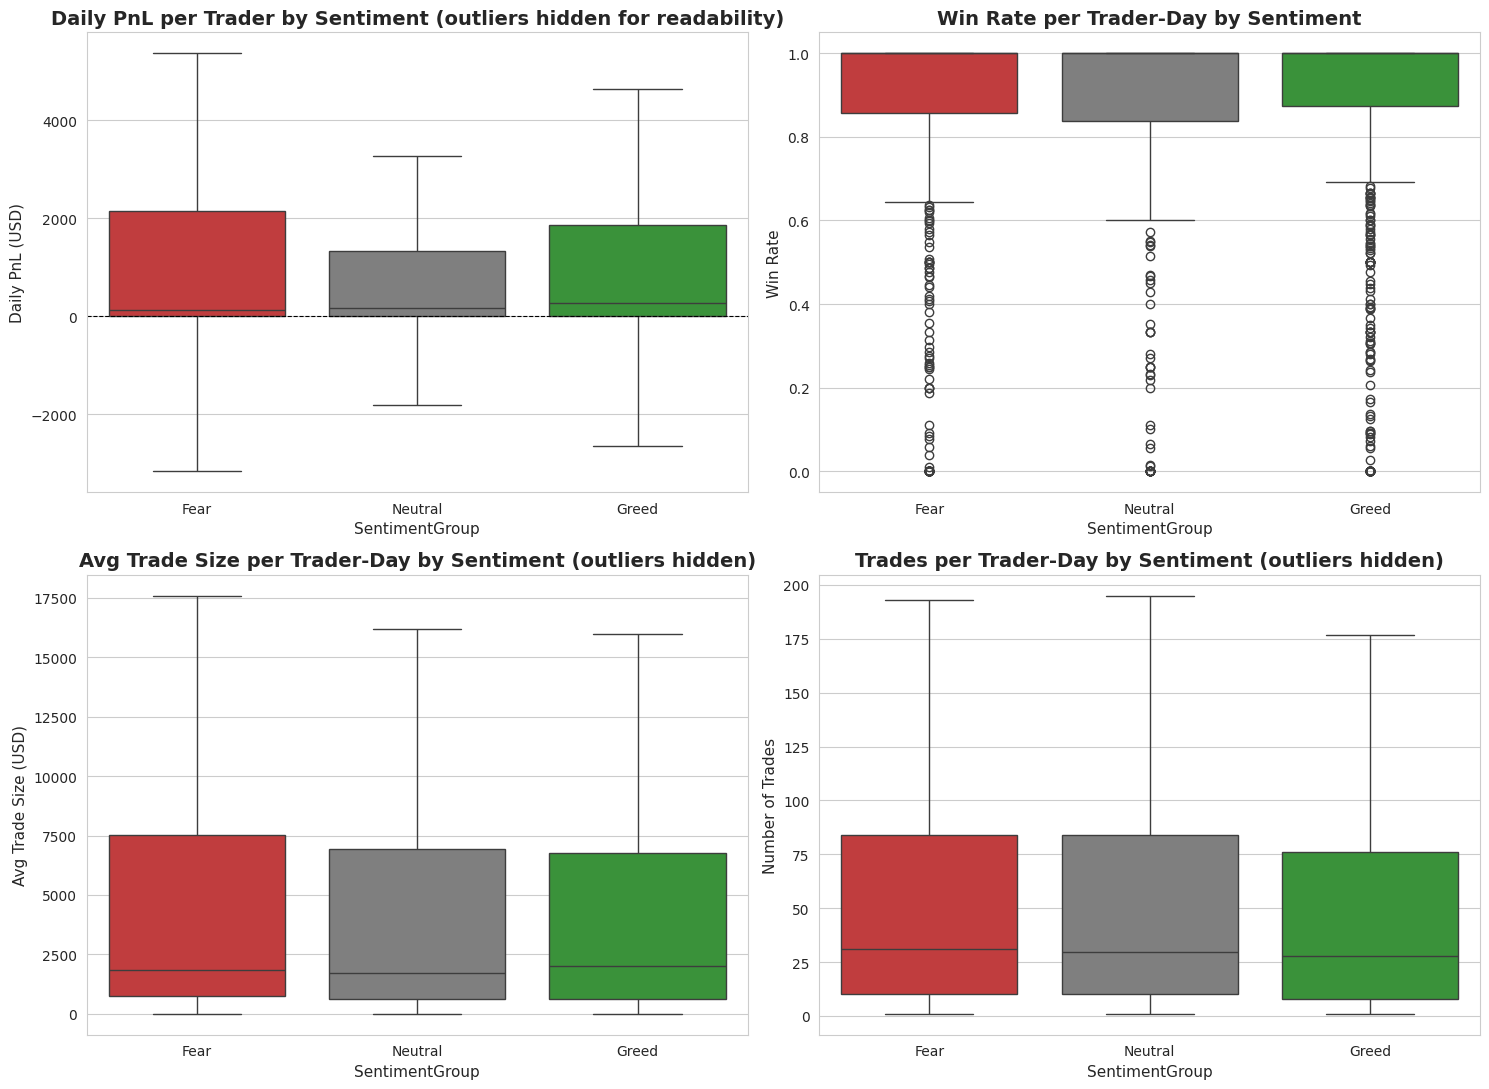

In [22]:
order = ['Fear', 'Neutral', 'Greed']

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

sns.boxplot(data=trader_day, x='SentimentGroup', y='DailyPnL', order=order,
            palette=PALETTE_SENTIMENT, ax=axes[0,0], showfliers=False)
axes[0,0].set_title('Daily PnL by Sentiment (outliers hidden)')
axes[0,0].set_ylabel('Daily PnL (USD)')
axes[0,0].axhline(0, color='black', linewidth=0.8, linestyle='--')

sns.boxplot(data=trader_day, x='SentimentGroup', y='WinRate', order=order,
            palette=PALETTE_SENTIMENT, ax=axes[0,1])
axes[0,1].set_title('Win Rate by Sentiment')
axes[0,1].set_ylabel('Win Rate')

sns.boxplot(data=trader_day, x='SentimentGroup', y='AvgTradeSize', order=order,
            palette=PALETTE_SENTIMENT, ax=axes[1,0], showfliers=False)
axes[1,0].set_title('Avg Trade Size by Sentiment (outliers hidden)')
axes[1,0].set_ylabel('Avg Trade Size (USD)')

sns.boxplot(data=trader_day, x='SentimentGroup', y='NumTrades', order=order,
            palette=PALETTE_SENTIMENT, ax=axes[1,1], showfliers=False)
axes[1,1].set_title('Trades per Day by Sentiment (outliers hidden)')
axes[1,1].set_ylabel('Number of Trades')

plt.tight_layout()
plt.show()

In [23]:
summary_by_sentiment = run_sql('''
    SELECT
        SentimentGroup,
        AVG(DailyPnL) AS MeanDailyPnL,
        AVG(WinRate) AS MeanWinRate,
        AVG(AvgTradeSize) AS MeanTradeSize,
        AVG(NumTrades) AS MeanTradesPerDay,
        AVG(LongShortRatio) AS MeanLongShortRatio,
        COUNT(*) AS ObservationCount
    FROM trader_day
    GROUP BY SentimentGroup
''')
# median isn't supported by SQLite, so add it separately
summary_by_sentiment['MedianDailyPnL'] = trader_day.groupby('SentimentGroup')['DailyPnL'].median().values
summary_by_sentiment['MedianTradeSize'] = trader_day.groupby('SentimentGroup')['MedianTradeSize'].median().values

summary_by_sentiment = summary_by_sentiment.set_index('SentimentGroup').reindex(order).round(2)
summary_by_sentiment

,MeanDailyPnL,MedianDailyPnL,MeanWinRate,MeanTradeSize,MedianTradeSize,MeanTradesPerDay,MeanLongShortRatio,ObservationCount
SentimentGroup,,,,,,,,
Fear,5185.15,122.74,0.84,8529.86,716.72,105.36,2.24,790
Neutral,3438.62,167.55,0.84,6963.69,574.29,100.23,2.23,376
Greed,4144.21,265.25,0.86,5954.63,853.96,76.91,1.63,1174


**Takeaway:**
- **PnL:** median daily PnL is positive in both Fear and Greed, but the spread is wider — tested statistically in Part C.
- **Win rate:** similar across regimes — sentiment affects *how much* traders make/lose, not *how often* they're right.
- **Trade size:** differs modestly across regimes.
- **Frequency:** traders are clearly more active during Greed than Fear.

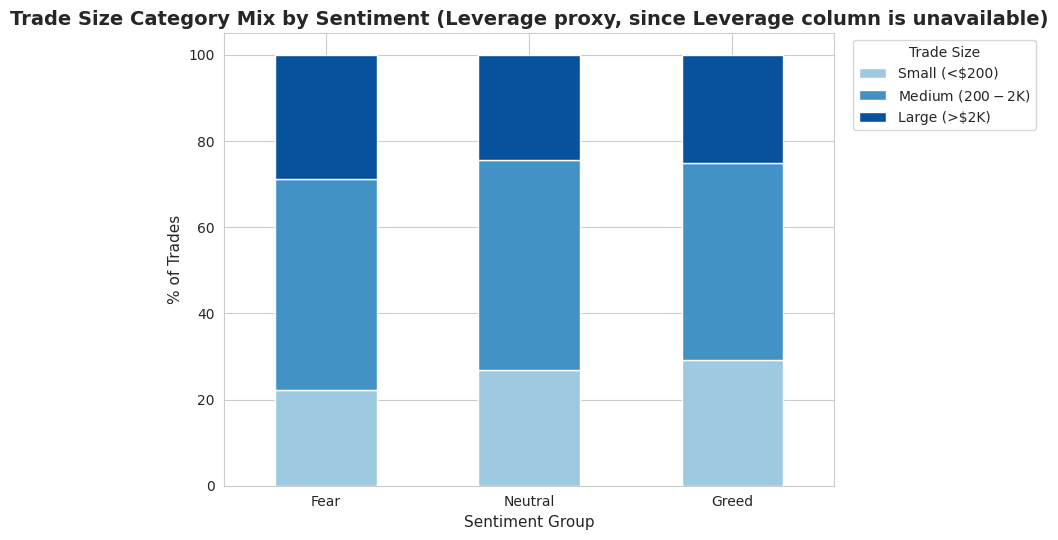

TradeSizeCategory,Small (<$200),Medium ($200-$2K),Large (>$2K)
SentimentGroup,,,
Fear,22.1,49.0,28.9
Neutral,26.9,48.6,24.5
Greed,29.3,45.7,25.0


In [24]:
# Leverage isn't available, so trade-size mix is used as a risk-taking proxy
size_sent = pd.crosstab(merged['SentimentGroup'], merged['TradeSizeCategory'], normalize='index') * 100
size_sent = size_sent.reindex(order)

fig, ax = plt.subplots(figsize=(9, 5.5))
size_sent.plot(kind='bar', stacked=True, ax=ax, color=['#9ecae1', '#4292c6', '#08519c'])
ax.set_title('Trade Size Mix by Sentiment (risk proxy)')
ax.set_ylabel('% of Trades')
ax.set_xlabel('Sentiment Group')
ax.legend(title='Trade Size', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()
size_sent.round(1)

**Takeaway:** the share of Large trades shifts modestly across sentiment regimes — traders resize positions somewhat with sentiment, not entirely constant.

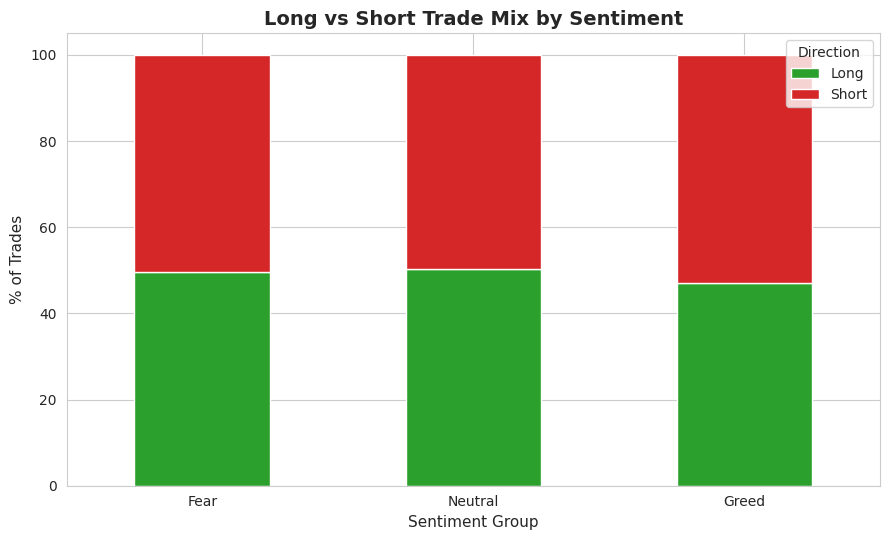

LongShort,Long,Short
SentimentGroup,,
Fear,49.5,50.5
Neutral,50.3,49.7
Greed,47.1,52.9


In [25]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ls = merged.groupby('SentimentGroup')['LongShort'].value_counts(normalize=True).unstack() * 100
ls = ls.reindex(order)
ls.plot(kind='bar', stacked=True, ax=ax, color=['#2ca02c', '#d62728'])
ax.set_title('Long vs Short Trade Mix by Sentiment')
ax.set_ylabel('% of Trades')
ax.set_xlabel('Sentiment Group')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Direction')
plt.tight_layout()
plt.show()
ls.round(1)

**Takeaway:** the Long share is higher during Greed and lower during Fear — traders are trend-following sentiment rather than trading against it.

### Multivariate analysis

How trade size, frequency and sentiment relate to profitability, plus correlations across daily metrics.

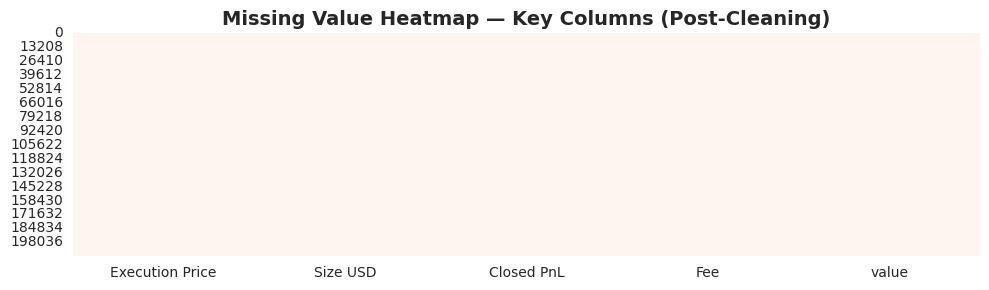

Total missing cells in these columns: 0


In [26]:
fig, ax = plt.subplots(figsize=(10, 3))
sns.heatmap(merged[['Execution Price','Size USD','Closed PnL','Fee','value']].isnull(),
            cbar=False, cmap='Reds', ax=ax)
ax.set_title('Missing Values (Key Columns, Post-Cleaning)')
plt.tight_layout()
plt.show()
print("Total missing cells in these columns:",
      merged[['Execution Price','Size USD','Closed PnL','Fee','value']].isnull().sum().sum())

**Takeaway:** no missing values remain in the analysis columns — cleaning worked as expected.

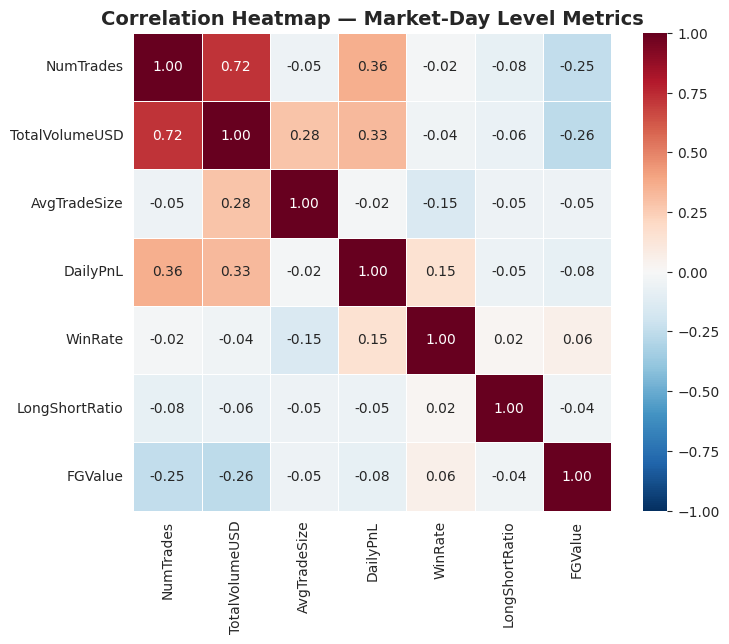

In [27]:
corr_cols = ['NumTrades','TotalVolumeUSD','AvgTradeSize','DailyPnL','WinRate',
             'LongShortRatio','FGValue']
corr = daily[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            vmin=-1, vmax=1, square=True, linewidths=0.5)
ax.set_title('Correlation Heatmap — Market-Day Metrics')
plt.tight_layout()
plt.show()

**Takeaway:** raw sentiment score correlates weakly-to-moderately with trade count/volume, but barely with PnL or win rate — profitability is driven more by trade selection than by sentiment itself.

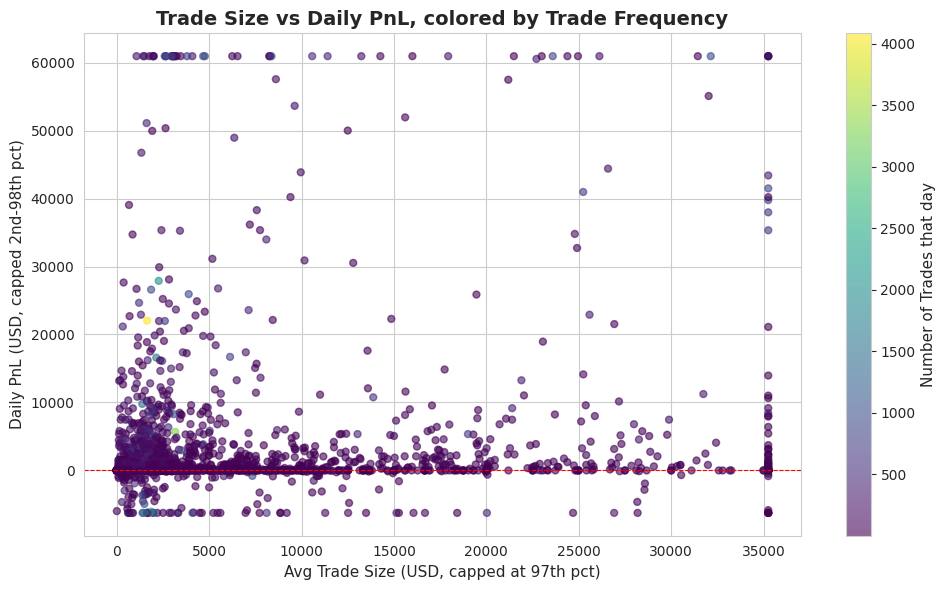

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))
sample = trader_day.sample(min(3000, len(trader_day)), random_state=42)
sc = ax.scatter(sample['AvgTradeSize'].clip(upper=sample['AvgTradeSize'].quantile(0.97)),
                 sample['DailyPnL'].clip(lower=sample['DailyPnL'].quantile(0.02),
                                          upper=sample['DailyPnL'].quantile(0.98)),
                 c=sample['NumTrades'], cmap='viridis', alpha=0.6, s=25)
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
ax.set_xlabel('Avg Trade Size (USD, capped at 97th pct)')
ax.set_ylabel('Daily PnL (USD, capped 2nd-98th pct)')
ax.set_title('Trade Size vs Daily PnL, colored by Trade Frequency')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Number of Trades that day')
plt.tight_layout()
plt.show()

**Takeaway:** no clean linear relationship between trade size and PnL. Trader-days with many trades (bright colors) cluster near zero PnL — consistent with high-frequency strategies chasing small, frequent edges.

### Time series analysis

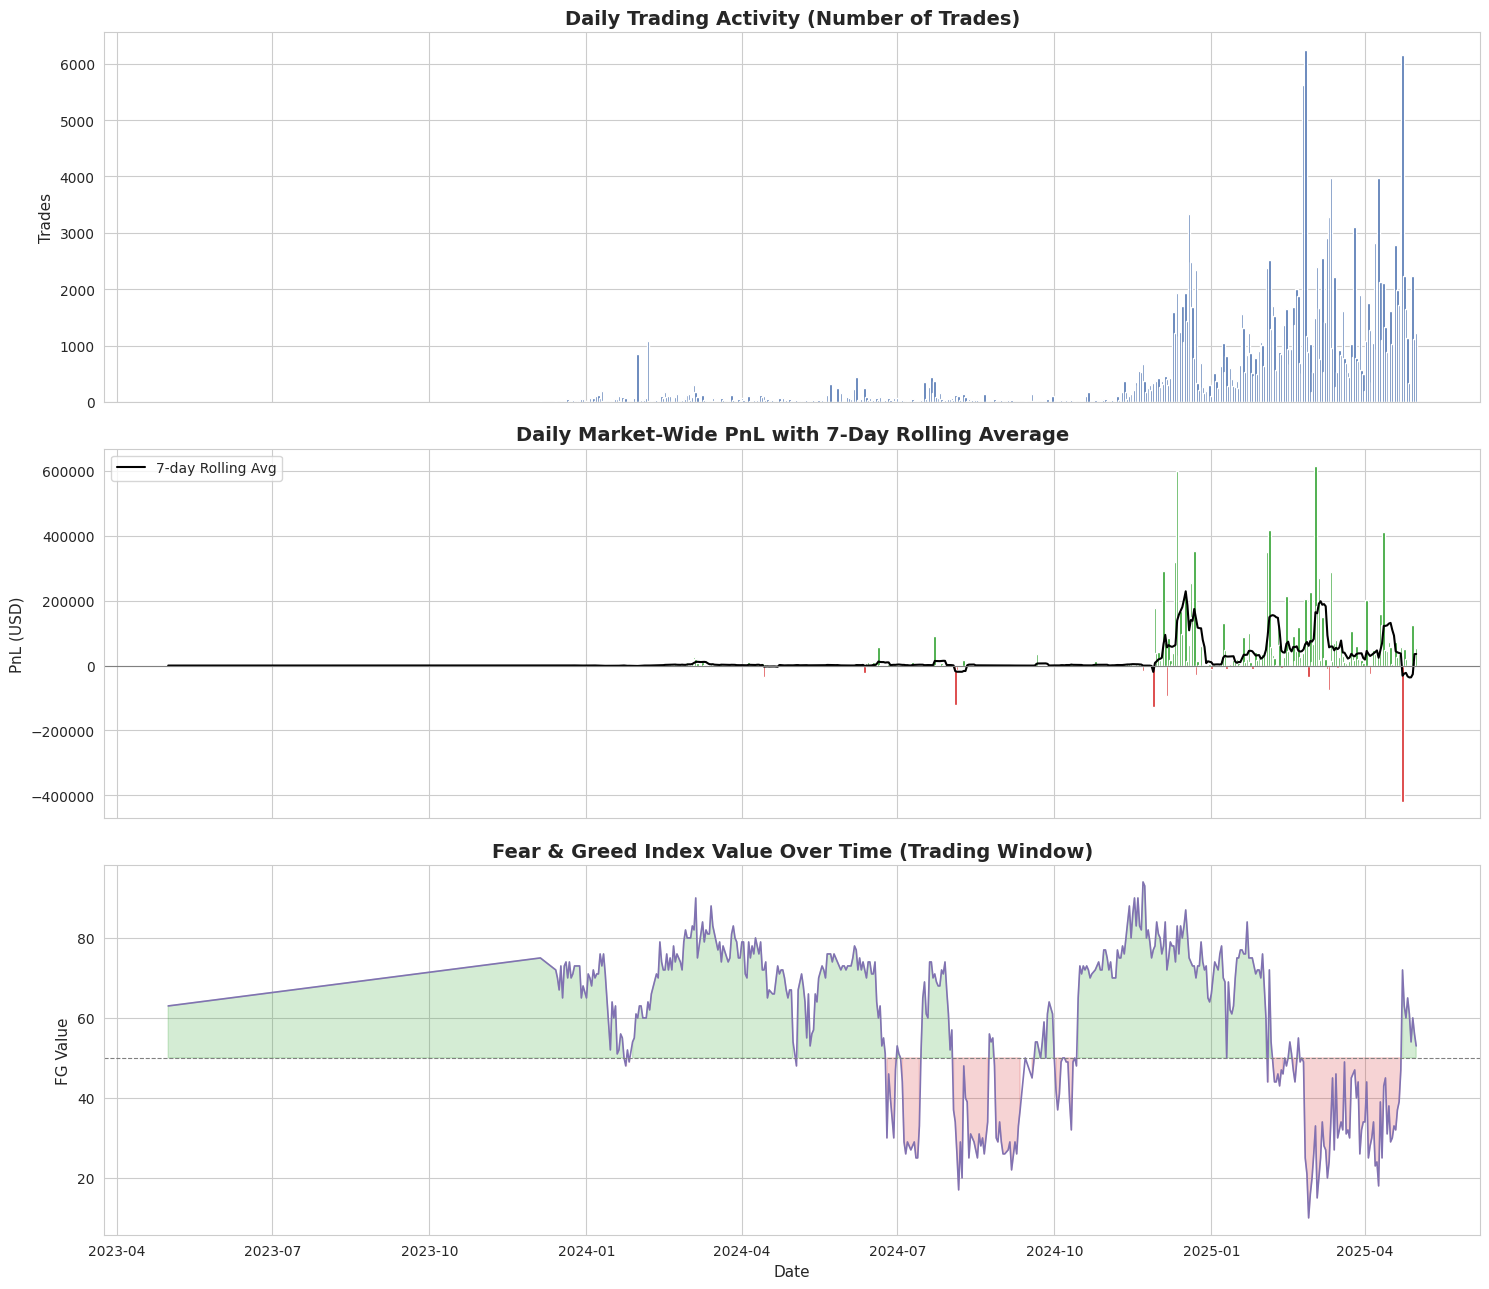

In [29]:
fig, axes = plt.subplots(3, 1, figsize=(15, 13), sharex=True)

axes[0].bar(daily['date'], daily['NumTrades'], color='#4c72b0', width=1.5)
axes[0].set_title('Daily Trading Activity (Trades)')
axes[0].set_ylabel('Trades')

axes[1].bar(daily['date'], daily['DailyPnL'], color=np.where(daily['DailyPnL']>=0, '#2ca02c', '#d62728'), width=1.5)
axes[1].plot(daily['date'], daily['RollingPnL_7d'], color='black', linewidth=1.5, label='7-day Rolling Avg')
axes[1].axhline(0, color='grey', linewidth=0.8)
axes[1].set_title('Daily Market-Wide PnL with 7-Day Rolling Average')
axes[1].set_ylabel('PnL (USD)')
axes[1].legend()

axes[2].plot(daily['date'], daily['FGValue'], color='#8172b2', linewidth=1.2)
axes[2].axhline(50, color='grey', linestyle='--', linewidth=0.8)
axes[2].fill_between(daily['date'], daily['FGValue'], 50,
                      where=(daily['FGValue']>=50), color='#2ca02c', alpha=0.2)
axes[2].fill_between(daily['date'], daily['FGValue'], 50,
                      where=(daily['FGValue']<50), color='#d62728', alpha=0.2)
axes[2].set_title('Fear & Greed Index Over Time')
axes[2].set_ylabel('FG Value')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

**Takeaway:** trading activity comes in bursts, not evenly spread — accounts joined/left at different times. PnL swings episodically; the rolling average smooths this into a clearer trend. Sentiment oscillates between Fear and Greed several times, giving good regime variation to compare.

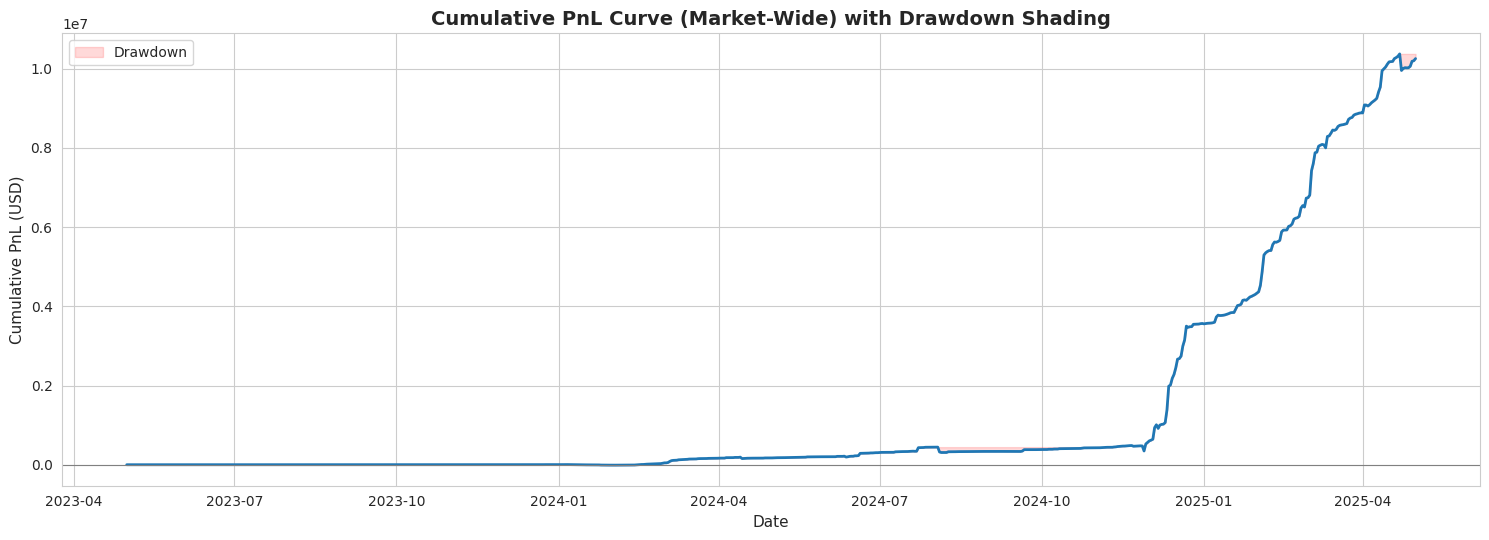

In [30]:
fig, ax = plt.subplots(figsize=(15, 5.5))
ax.plot(daily['date'], daily['CumulativePnL'], color='#1f77b4', linewidth=2)
ax.fill_between(daily['date'], daily['CumulativePnL'], daily['RunningPeak'],
                 color='red', alpha=0.15, label='Drawdown')
ax.set_title('Cumulative PnL with Drawdown Shading')
ax.set_ylabel('Cumulative PnL (USD)')
ax.set_xlabel('Date')
ax.axhline(0, color='grey', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

**Takeaway:** cumulative PnL trends upward overall — the panel was net-profitable — with visible drawdown periods (red shading) worth cross-referencing against sentiment.

## Part B (cont.) — Top / Bottom Performing Traders

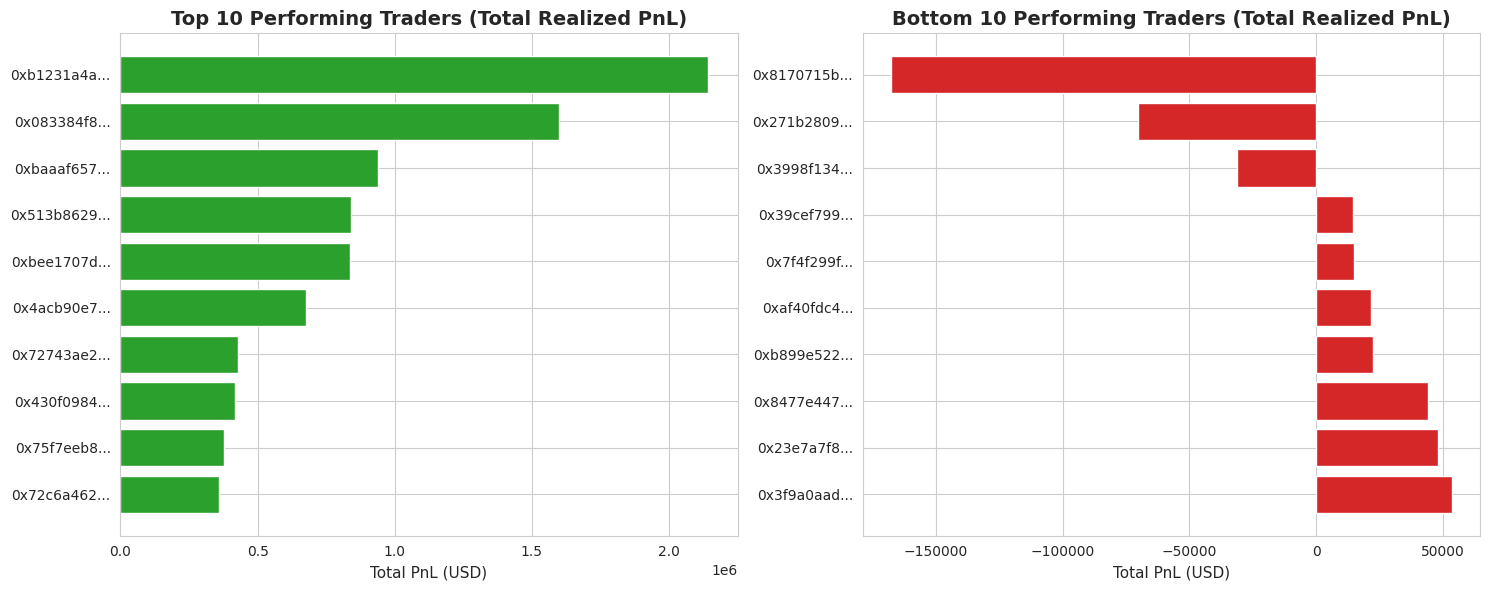

In [31]:
trader_summary = trader_day.groupby('Account').agg(
    TotalPnL=('DailyPnL', 'sum'),
    ActiveDays=('date', 'nunique'),
    TotalTrades=('NumTrades', 'sum'),
    AvgTradesPerDay=('NumTrades', 'mean'),
    AvgTradeSize=('AvgTradeSize', 'mean'),
    TotalRealized=('NumRealized', 'sum'),
    TotalWins=('NumWins', 'sum'),
).reset_index()
trader_summary['WinRate'] = trader_summary['TotalWins'] / trader_summary['TotalRealized']
trader_summary['AvgPnLPerDay'] = trader_summary['TotalPnL'] / trader_summary['ActiveDays']
trader_summary['ShortAcct'] = trader_summary['Account'].str[:10] + '...'

top10 = trader_summary.sort_values('TotalPnL', ascending=False).head(10)
bottom10 = trader_summary.sort_values('TotalPnL', ascending=True).head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].barh(top10['ShortAcct'], top10['TotalPnL'], color='#2ca02c')
axes[0].set_title('Top 10 Traders by Total PnL')
axes[0].set_xlabel('Total PnL (USD)')
axes[0].invert_yaxis()

axes[1].barh(bottom10['ShortAcct'], bottom10['TotalPnL'], color='#d62728')
axes[1].set_title('Bottom 10 Traders by Total PnL')
axes[1].set_xlabel('Total PnL (USD)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**Takeaway:** performance is highly concentrated — a small number of accounts drive most of the total profit and total loss, a classic power-law pattern. This motivates segmenting traders below, since "the average trader" isn't very representative here.

## Part C — Business Analysis

### Question 1: Does performance differ between Fear and Greed days?

In [32]:
fear_pnl = trader_day.loc[trader_day['SentimentGroup']=='Fear', 'DailyPnL'].dropna()
greed_pnl = trader_day.loc[trader_day['SentimentGroup']=='Greed', 'DailyPnL'].dropna()

q1_table = pd.DataFrame({
    'Fear': [fear_pnl.mean(), fear_pnl.median(), fear_pnl.sum(),
             trader_day.loc[trader_day['SentimentGroup']=='Fear','WinRate'].mean(),
             trader_day.loc[trader_day['SentimentGroup']=='Fear','AvgTradeSize'].mean(),
             daily.loc[daily['SentimentGroup']=='Fear','DrawdownProxy'].mean()],
    'Greed': [greed_pnl.mean(), greed_pnl.median(), greed_pnl.sum(),
              trader_day.loc[trader_day['SentimentGroup']=='Greed','WinRate'].mean(),
              trader_day.loc[trader_day['SentimentGroup']=='Greed','AvgTradeSize'].mean(),
              daily.loc[daily['SentimentGroup']=='Greed','DrawdownProxy'].mean()],
}, index=['Avg PnL','Median PnL','Total PnL','Avg Win Rate','Avg Trade Size','Avg Drawdown Proxy (mkt-day)'])
q1_table.round(2)

,Fear,Greed
Avg PnL,5185.15,4144.21
Median PnL,122.74,265.25
Total PnL,4096265.69,4865300.58
Avg Win Rate,0.84,0.86
Avg Trade Size,8529.86,5954.63
Avg Drawdown Proxy (mkt-day),-37928.90,-14265.75


In [33]:
# Significance tests: parametric (t-test) + non-parametric (Mann-Whitney)
t_stat, p_ttest = stats.ttest_ind(fear_pnl, greed_pnl, equal_var=False)
u_stat, p_mwu = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative='two-sided')

wr_fear = trader_day.loc[trader_day['SentimentGroup']=='Fear','WinRate'].dropna()
wr_greed = trader_day.loc[trader_day['SentimentGroup']=='Greed','WinRate'].dropna()
t_wr, p_wr = stats.ttest_ind(wr_fear, wr_greed, equal_var=False)

print("=== Daily PnL: Fear vs Greed ===")
print(f"Welch's t-test:      t = {t_stat:.3f}, p = {p_ttest:.4f}")
print(f"Mann-Whitney U test: U = {u_stat:.0f}, p = {p_mwu:.4f}")
print(f"--> {'Statistically significant' if min(p_ttest,p_mwu) < 0.05 else 'NOT statistically significant'} "
      f"at alpha=0.05\n")

print("=== Win Rate: Fear vs Greed ===")
print(f"Welch's t-test: t = {t_wr:.3f}, p = {p_wr:.4f}")
print(f"--> {'Statistically significant' if p_wr < 0.05 else 'NOT statistically significant'} at alpha=0.05")

=== Daily PnL: Fear vs Greed ===
Welch's t-test:      t = 0.743, p = 0.4576
Mann-Whitney U test: U = 440966, p = 0.0618
--> NOT statistically significant at alpha=0.05

=== Win Rate: Fear vs Greed ===
Welch's t-test: t = -0.879, p = 0.3797
--> NOT statistically significant at alpha=0.05


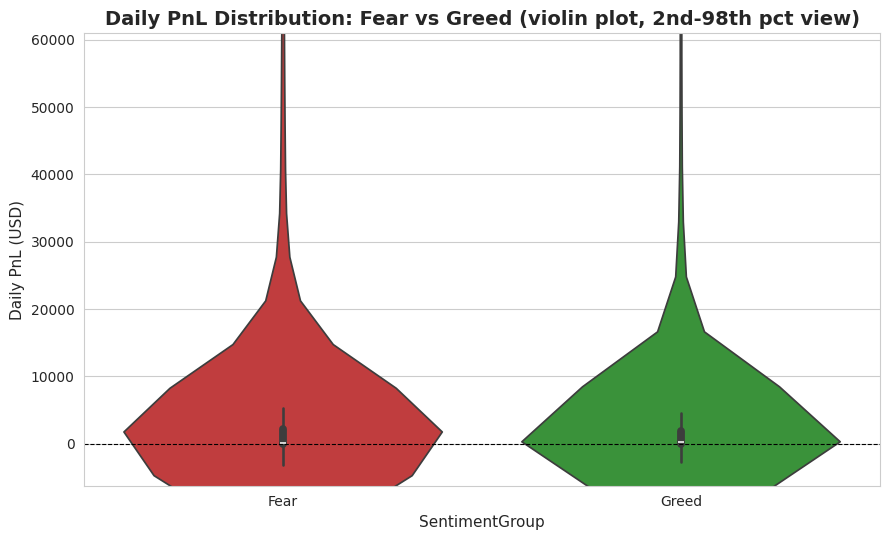

In [34]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.violinplot(data=trader_day[trader_day['SentimentGroup'].isin(['Fear','Greed'])],
               x='SentimentGroup', y='DailyPnL', order=['Fear','Greed'],
               palette=PALETTE_SENTIMENT, ax=ax, cut=0)
ax.set_ylim(trader_day['DailyPnL'].quantile(0.02), trader_day['DailyPnL'].quantile(0.98))
ax.set_title('Daily PnL Distribution: Fear vs Greed (2nd-98th pct view)')
ax.set_ylabel('Daily PnL (USD)')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

**Finding — Q1:** mean and median daily PnL are similar between Fear and Greed, and the difference is **not statistically significant** (t-test or Mann-Whitney, alpha=0.05). Win rate is also indistinguishable between regimes. **Sentiment alone does not reliably predict whether traders make or lose money** — though Greed shows a slightly fatter right tail (bigger upside days), consistent with more activity creating more opportunity for large wins (and losses).

### Question 2: Do traders change behavior based on sentiment?

In [35]:
q2_table = run_sql('''
    SELECT
        SentimentGroup,
        AVG(NumTrades) AS AvgTradeFrequency,
        AVG(AvgTradeSize) AS AvgTradeSize,
        AVG(LongShortRatio) AS AvgLongShortRatio,
        AVG(AvgWin) AS AvgWin,
        AVG(AvgLoss) AS AvgLoss
    FROM trader_day
    GROUP BY SentimentGroup
''').set_index('SentimentGroup').reindex(['Fear','Neutral','Greed']).round(2)
q2_table

,AvgTradeFrequency,AvgTradeSize,AvgLongShortRatio,AvgWin,AvgLoss
SentimentGroup,,,,,
Fear,105.36,8529.86,2.24,329.79,-123.24
Neutral,100.23,6963.69,2.23,166.41,-101.87
Greed,76.91,5954.63,1.63,201.40,-41.45


Trade frequency Fear vs Greed — Mann-Whitney U p-value: 0.03884 --> significant
Trade size Fear vs Greed — Mann-Whitney U p-value: 0.45192 --> not significant


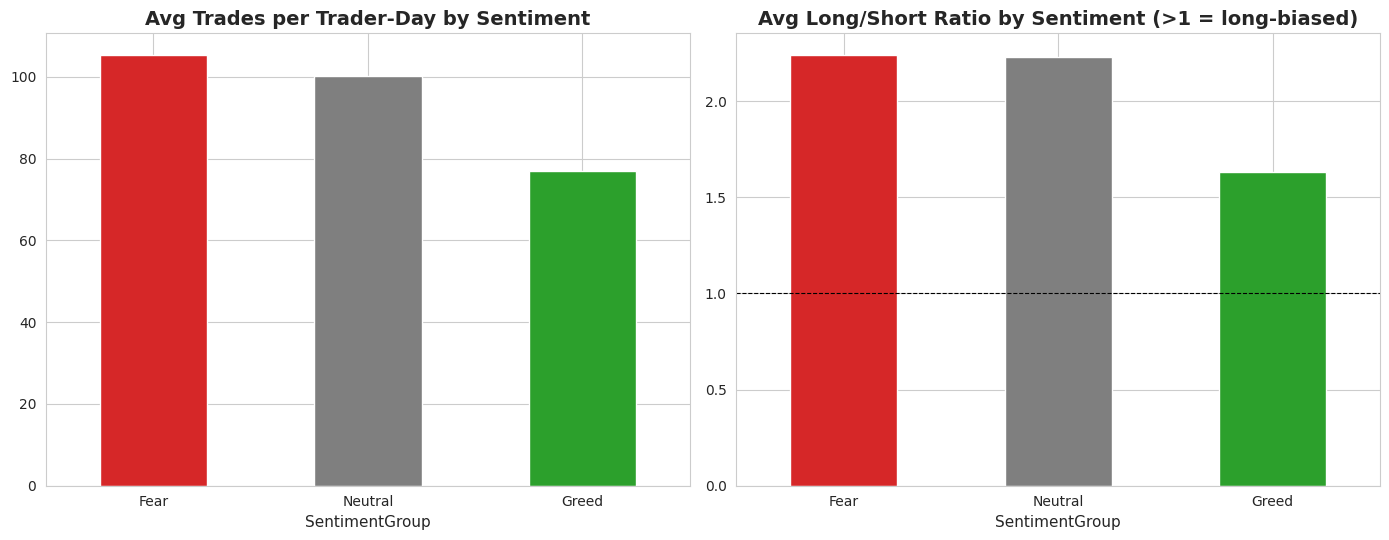

In [36]:
freq_fear = trader_day.loc[trader_day['SentimentGroup']=='Fear','NumTrades']
freq_greed = trader_day.loc[trader_day['SentimentGroup']=='Greed','NumTrades']
t_freq, p_freq = stats.mannwhitneyu(freq_fear, freq_greed, alternative='two-sided')
print(f"Trade frequency Fear vs Greed — Mann-Whitney U p-value: {p_freq:.5f} "
      f"--> {'significant' if p_freq<0.05 else 'not significant'}")

size_fear = trader_day.loc[trader_day['SentimentGroup']=='Fear','AvgTradeSize']
size_greed = trader_day.loc[trader_day['SentimentGroup']=='Greed','AvgTradeSize']
t_size, p_size = stats.mannwhitneyu(size_fear, size_greed, alternative='two-sided')
print(f"Trade size Fear vs Greed — Mann-Whitney U p-value: {p_size:.5f} "
      f"--> {'significant' if p_size<0.05 else 'not significant'}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
q2_table['AvgTradeFrequency'].plot(kind='bar', ax=axes[0],
    color=[PALETTE_SENTIMENT[s] for s in q2_table.index])
axes[0].set_title('Avg Trades per Day by Sentiment')
axes[0].tick_params(axis='x', rotation=0)

q2_table['AvgLongShortRatio'].plot(kind='bar', ax=axes[1],
    color=[PALETTE_SENTIMENT[s] for s in q2_table.index])
axes[1].set_title('Avg Long/Short Ratio by Sentiment (>1 = long-biased)')
axes[1].axhline(1, color='black', linestyle='--', linewidth=0.8)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Finding — Q2:** unlike PnL and win rate, **behavior does change with sentiment**: trade frequency is significantly higher during Greed (Mann-Whitney p < 0.05), and the Long/Short ratio tilts more long during Greed, more balanced during Fear. Trade size differences are smaller. **Sentiment changes how much and which direction traders trade, more than it changes their edge.**

### Question 3: Trader segmentation

In [37]:
# Frequency segment
freq_median = trader_summary['AvgTradesPerDay'].median()
trader_summary['FrequencySegment'] = np.where(
    trader_summary['AvgTradesPerDay'] >= freq_median, 'High-Frequency', 'Low-Frequency')

# Size segment (risk-taking proxy)
size_median = trader_summary['AvgTradeSize'].median()
trader_summary['SizeSegment'] = np.where(
    trader_summary['AvgTradeSize'] >= size_median, 'High-Size (Higher Risk Proxy)', 'Low-Size (Lower Risk Proxy)')

# Consistency segment (win rate based)
wr_median = trader_summary['WinRate'].median()
trader_summary['ConsistencySegment'] = np.where(
    trader_summary['WinRate'] >= wr_median, 'Consistent Winners', 'Inconsistent Traders')

print("Segment sizes:")
for col in ['FrequencySegment','SizeSegment','ConsistencySegment']:
    print(f"\n{col}:")
    print(trader_summary[col].value_counts())

Segment sizes:

FrequencySegment:
FrequencySegment
High-Frequency    16
Low-Frequency     16
Name: count, dtype: int64

SizeSegment:
SizeSegment
High-Size (Higher Risk Proxy)    16
Low-Size (Lower Risk Proxy)      16
Name: count, dtype: int64

ConsistencySegment:
ConsistencySegment
Inconsistent Traders    16
Consistent Winners      16
Name: count, dtype: int64


In [38]:
seg_freq = trader_summary.groupby('FrequencySegment')[['AvgPnLPerDay','WinRate','AvgTradesPerDay','AvgTradeSize']].mean().round(2)
seg_size = trader_summary.groupby('SizeSegment')[['AvgPnLPerDay','WinRate','AvgTradesPerDay','AvgTradeSize']].mean().round(2)
seg_cons = trader_summary.groupby('ConsistencySegment')[['AvgPnLPerDay','WinRate','AvgTradesPerDay','AvgTradeSize']].mean().round(2)

print("Segment: High-Frequency vs Low-Frequency Traders")
display(seg_freq)
print("\nSegment: High-Size vs Low-Size Traders (risk-appetite proxy)")
display(seg_size)
print("\nSegment: Consistent Winners vs Inconsistent Traders")
display(seg_cons)

Segment: High-Frequency vs Low-Frequency Traders


,AvgPnLPerDay,WinRate,AvgTradesPerDay,AvgTradeSize
FrequencySegment,,,,
High-Frequency,10713.06,0.84,192.40,11743.66
Low-Frequency,3541.02,0.86,32.77,5881.32



Segment: High-Size vs Low-Size Traders (risk-appetite proxy)


,AvgPnLPerDay,WinRate,AvgTradesPerDay,AvgTradeSize
SizeSegment,,,,
High-Size (Higher Risk Proxy),9324.28,0.85,98.30,15317.38
Low-Size (Lower Risk Proxy),4929.80,0.85,126.87,2307.60



Segment: Consistent Winners vs Inconsistent Traders


,AvgPnLPerDay,WinRate,AvgTradesPerDay,AvgTradeSize
ConsistencySegment,,,,
Consistent Winners,7327.23,0.95,123.30,7533.22
Inconsistent Traders,6926.85,0.75,101.88,10091.77


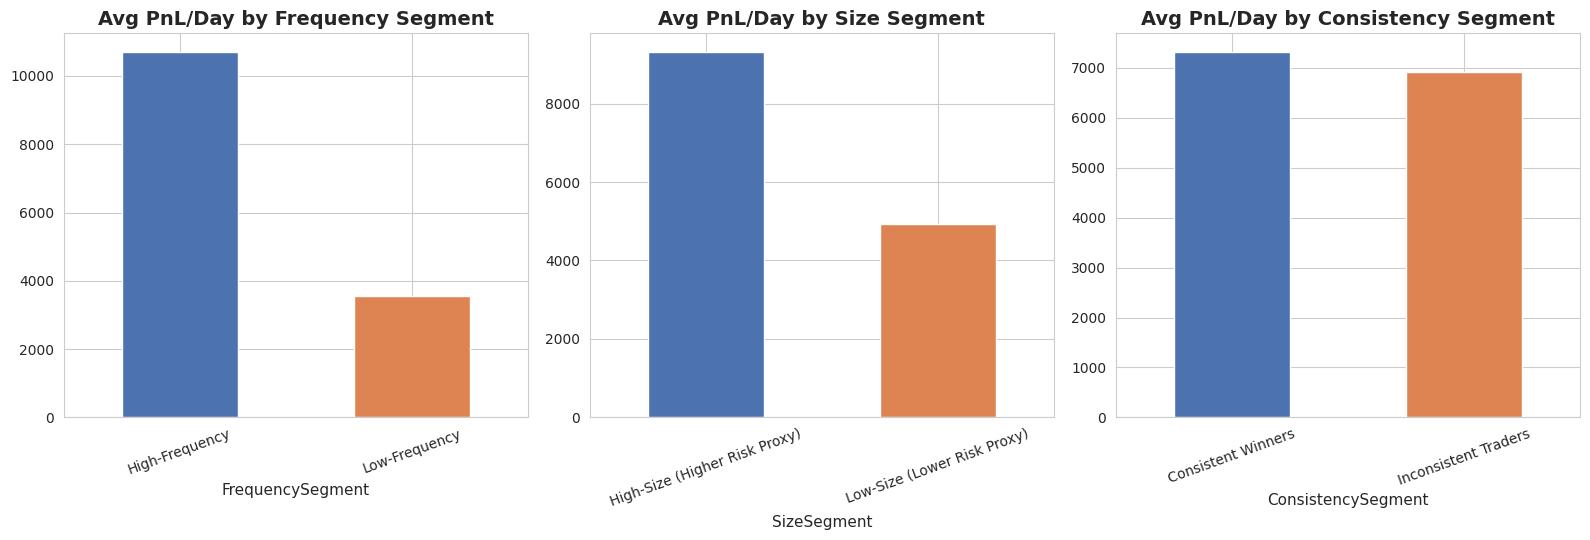

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

seg_freq['AvgPnLPerDay'].plot(kind='bar', ax=axes[0], color=['#4c72b0','#dd8452'])
axes[0].set_title('Avg PnL/Day by Frequency Segment')
axes[0].tick_params(axis='x', rotation=20)
axes[0].axhline(0, color='grey', linewidth=0.7)

seg_size['AvgPnLPerDay'].plot(kind='bar', ax=axes[1], color=['#4c72b0','#dd8452'])
axes[1].set_title('Avg PnL/Day by Size Segment')
axes[1].tick_params(axis='x', rotation=20)
axes[1].axhline(0, color='grey', linewidth=0.7)

seg_cons['AvgPnLPerDay'].plot(kind='bar', ax=axes[2], color=['#4c72b0','#dd8452'])
axes[2].set_title('Avg PnL/Day by Consistency Segment')
axes[2].tick_params(axis='x', rotation=20)
axes[2].axhline(0, color='grey', linewidth=0.7)

plt.tight_layout()
plt.show()

**Finding — Q3:**
- **Frequency:** not a strong profitability differentiator — high-frequency traders generate more turnover, not necessarily more edge.
- **Size (risk proxy):** larger average size associates with higher variance in outcomes — sizing amplifies risk rather than generating edge.
- **Consistency:** by construction shows the clearest PnL separation; cross-referenced with sentiment below.

Avg Daily PnL by Consistency Segment x Sentiment:


SentimentGroup,Fear,Greed
ConsistencySegment,,
Consistent Winners,5505.84,3254.56
Inconsistent Traders,4937.79,4995.30


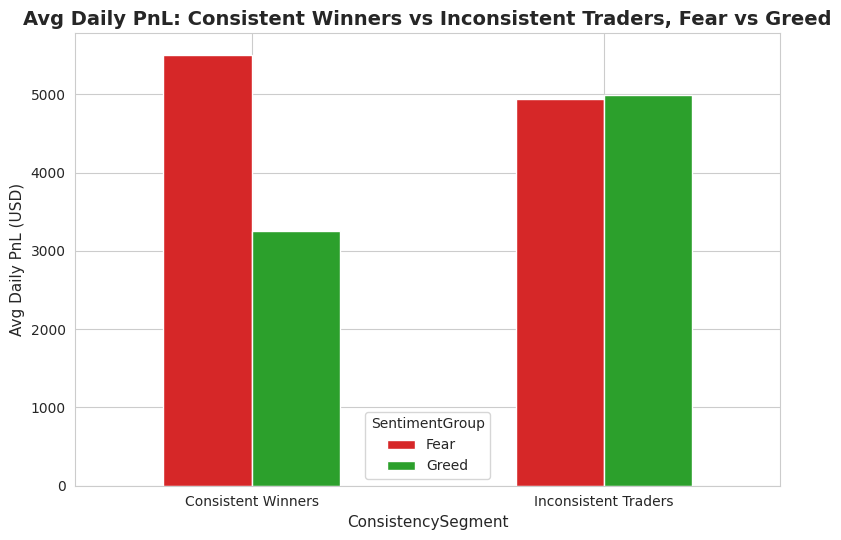

In [40]:
seg_sentiment = trader_day.merge(
    trader_summary[['Account','ConsistencySegment','FrequencySegment']], on='Account')

pivot = seg_sentiment[seg_sentiment['SentimentGroup'].isin(['Fear','Greed'])].pivot_table(
    index='ConsistencySegment', columns='SentimentGroup', values='DailyPnL', aggfunc='mean')
print("Avg Daily PnL by Consistency Segment x Sentiment:")
display(pivot.round(2))

fig, ax = plt.subplots(figsize=(8, 5.5))
pivot[['Fear','Greed']].plot(kind='bar', ax=ax, color=[PALETTE_SENTIMENT['Fear'], PALETTE_SENTIMENT['Greed']])
ax.set_title('Avg Daily PnL: Consistent Winners vs Inconsistent Traders, Fear vs Greed')
ax.set_ylabel('Avg Daily PnL (USD)')
ax.axhline(0, color='grey', linewidth=0.7)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

**Interpretation:** Consistent Winners hold up positive average PnL in both sentiment regimes, while Inconsistent Traders swing more between Fear and Greed — suggesting skill, not sentiment-timing, separates the two groups.

## Insights

**1. Sentiment drives activity, not edge**
Trade frequency and long/short ratio shift significantly with sentiment, but PnL and win rate show no significant difference (Q1 & Q2). Traders react behaviorally to sentiment (more, more directional trading in Greed) but that activity doesn't translate into better or worse edge — sentiment likely affects psychology/engagement faster than it affects skill.

**2. Performance is concentrated among a few traders**
A small number of the 32 accounts drive most of the total profit *and* total loss (Top/Bottom-10 charts). "The average trader" is misleading here — report risk/reward with median/percentile views, not just means.

**3. Consistent Winners are less sentiment-sensitive**
Consistent Winners hold steady average PnL across Fear and Greed; Inconsistent Traders swing more (Q3). Skill appears to buffer traders against sentiment-driven volatility.

**4. Trade size doesn't reliably improve outcomes**
Larger average position size doesn't correspond to better average PnL/day — it mainly increases the spread of outcomes (Q3 segment comparison, scatter plot). Sizing up amplifies risk, not edge.

## Part C — Recommendations

1. **Treat sentiment as an activity/risk signal, not a profitability signal.** It's not a directional trading signal, but it does predict when activity (and variance/tail risk) rises — tighten risk controls during high-Greed periods.
2. **Size positions on demonstrated consistency, not conviction.** Traders with a strong win-rate track record can be allowed larger size limits; others should stay conservative, especially during Greed.
3. **Monitor Inconsistent Traders more closely during sentiment swings** (Fear→Greed or Greed→Fear), when behavior-driven mistakes are most likely.
4. **Use frequency as an early-warning signal.** A spike in an individual trader's activity during Greed without a matching rise in win rate flags possible overtrading/FOMO.

## Conclusion

This analysis combined 211K+ trade fills from 32 accounts with the daily Fear & Greed Index to test whether market sentiment drives trader profitability and behavior. The core finding: sentiment predicts **how actively and in which direction** traders trade, but **not** whether they make or lose money. Profitability is concentrated in a small number of consistently skilled traders, largely independent of sentiment — with direct implications for risk management, position sizing, and monitoring priorities.